In [1]:
from google.colab import userdata
from huggingface_hub import login

login(userdata.get("HF_TOKEN"))

In [2]:
# ==== Cell 1: Setup ====

# Check GPU first
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ==== Cell 2: Installs ====

!pip install -q transformers==4.55.4 datasets==4.3.0 huggingface_hub==0.34.4 evaluate==0.4.5 accelerate==1.10.1
!pip install -q "peft>=0.13" "bitsandbytes>=0.44" sacrebleu sentencepiece
!pip install -U "huggingface_hub==0.34.4"

In [4]:
import transformers, datasets, huggingface_hub, accelerate, peft, bitsandbytes
print(transformers.__version__, datasets.__version__, huggingface_hub.__version__)
print(accelerate.__version__, peft.__version__, bitsandbytes.__version__)

4.55.4 4.3.0 0.34.4
1.10.1 0.19.1 0.49.2


In [5]:
# ==== Cell 3: Sanity check — tokenizer + model round-trip ====

from transformers import MarianMTModel, MarianTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "Helsinki-NLP/opus-mt-en-de"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name, torch_dtype=torch.float16).to(DEVICE)

test_sentences = ["When I was young, I used to go to the park every day."]

inputs = tokenizer(test_sentences, return_tensors="pt", padding=True, truncation=True).to(DEVICE)

with torch.no_grad():
    generated_tokens = model.generate(**inputs, max_length=256, num_beams=5)

translations = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

print("Input:", test_sentences[0])
print("Translation:", translations[0])

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Input: When I was young, I used to go to the park every day.
Translation: Als ich jung war, ging ich jeden Tag in den Park.


In [6]:
# ==== Cell 4: Load WMT14 En-De ====

from datasets import load_dataset

raw_dataset = load_dataset("regisss/wmt14-en-de-pre-processed")
print(raw_dataset)

# Peek at one example to confirm structure
print(raw_dataset["train"][0])

README.md:   0%|          | 0.00/812 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/281M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/266M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/276M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/341k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/474k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4548885 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 4548885
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2169
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2999
    })
})
{'translation': {'de': 'Wiederaufnahme der Sitzungsperiode', 'en': 'Resumption of the session'}}


In [7]:
# ==== Cell 5: Create train/eval subsets ====

TRAIN_SIZE = 20000
EVAL_SIZE = 300

train_subset = raw_dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
eval_subset = raw_dataset["test"].select(range(EVAL_SIZE))  # newstest2014, untouched until benchmarking

print(train_subset[0])
print(eval_subset[0])

{'translation': {'de': '(Ich weiß nicht, ob sie aber glaube nicht verkaufen).', 'en': '(I do not know if they sell but do not think so).'}}
{'translation': {'de': 'Obama empfängt Netanyahu', 'en': 'Obama receives Netanyahu'}}


In [8]:
# ==== Cell 6: Tokenize ====

MAX_LENGTH = 128

def preprocess_function(examples):
    inputs = [ex["en"] for ex in examples["translation"]]
    targets = [ex["de"] for ex in examples["translation"]]

    model_inputs = tokenizer(inputs, max_length=MAX_LENGTH, truncation=True)

    labels = tokenizer(text_target=targets, max_length=MAX_LENGTH, truncation=True)
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

tokenized_train = train_subset.map(preprocess_function, batched=True, remove_columns=["translation"])
tokenized_eval_for_training = eval_subset.map(preprocess_function, batched=True, remove_columns=["translation"])

print(tokenized_train[0])

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

{'input_ids': [20, 444, 156, 66, 253, 205, 141, 7303, 144, 156, 66, 569, 88, 122, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [20, 2449, 810, 51, 2, 628, 76, 179, 2787, 51, 4961, 122, 0]}


In [9]:
# ==== Cell 7: Find attention projection layer names ====

for name, module in model.named_modules():
    if "attn" in name and ("proj" in name):
        print(name)

model.encoder.layers.0.self_attn.k_proj
model.encoder.layers.0.self_attn.v_proj
model.encoder.layers.0.self_attn.q_proj
model.encoder.layers.0.self_attn.out_proj
model.encoder.layers.1.self_attn.k_proj
model.encoder.layers.1.self_attn.v_proj
model.encoder.layers.1.self_attn.q_proj
model.encoder.layers.1.self_attn.out_proj
model.encoder.layers.2.self_attn.k_proj
model.encoder.layers.2.self_attn.v_proj
model.encoder.layers.2.self_attn.q_proj
model.encoder.layers.2.self_attn.out_proj
model.encoder.layers.3.self_attn.k_proj
model.encoder.layers.3.self_attn.v_proj
model.encoder.layers.3.self_attn.q_proj
model.encoder.layers.3.self_attn.out_proj
model.encoder.layers.4.self_attn.k_proj
model.encoder.layers.4.self_attn.v_proj
model.encoder.layers.4.self_attn.q_proj
model.encoder.layers.4.self_attn.out_proj
model.encoder.layers.5.self_attn.k_proj
model.encoder.layers.5.self_attn.v_proj
model.encoder.layers.5.self_attn.q_proj
model.encoder.layers.5.self_attn.out_proj
model.decoder.layers.0.self_

In [10]:
# ==== Cell 8: Benchmark utilities ====

import time
import evaluate

bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    return total

def model_disk_size_mb(model, path="temp_model_ckpt"):
    model.save_pretrained(path)
    total_size = sum(
        os.path.getsize(os.path.join(dirpath, f))
        for dirpath, _, filenames in os.walk(path)
        for f in filenames
    )
    return total_size / (1024 ** 2)  # MB

def translate_batch(model, tokenizer, sentences, device, batch_size=16, max_length=128):
    translations = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
        with torch.no_grad():
            generated = model.generate(**inputs, max_length=max_length, num_beams=5)
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        translations.extend(decoded)
    return translations

def measure_latency(model, tokenizer, sentences, device, n_repeats=3):
    # warmup
    _ = translate_batch(model, tokenizer, sentences[:8], device)
    torch.cuda.synchronize() if device == "cuda" else None

    times = []
    for _ in range(n_repeats):
        start = time.time()
        _ = translate_batch(model, tokenizer, sentences, device)
        torch.cuda.synchronize() if device == "cuda" else None
        times.append(time.time() - start)

    avg_time = sum(times) / len(times)
    return avg_time / len(sentences)  # seconds per sentence

def evaluate_stage(model, tokenizer, eval_subset, device, stage_name, results_list):
    sources = [ex["en"] for ex in eval_subset["translation"]]
    references = [ex["de"] for ex in eval_subset["translation"]]

    predictions = translate_batch(model, tokenizer, sources, device)

    bleu = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    chrf = chrf_metric.compute(predictions=predictions, references=[[r] for r in references])

    latency = measure_latency(model, tokenizer, sources[:50], device)  # smaller sample for timing
    params = count_params(model)
    size_mb = model_disk_size_mb(model)

    result = {
        "stage": stage_name,
        "params": params,
        "size_mb": size_mb,
        "latency_sec_per_sentence": latency,
        "bleu": bleu["score"],
        "chrf": chrf["score"],
    }
    results_list.append(result)
    print(result)
    return predictions

In [11]:
import os
all_results = []  # will accumulate all 4 stages(base, base+lora ft, ft+quantized(8 bit), ft + quantized(4 bit))

In [12]:
# ==== Cell 9: Stage 1 — base pretrained benchmark ====

base_predictions = evaluate_stage(model, tokenizer, eval_subset, DEVICE, "1_base_pretrained", all_results)

# save a few example translations for the qualitative comparison later
example_translations = {"1_base_pretrained": base_predictions[:5]}

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


{'stage': '1_base_pretrained', 'params': 74410496, 'size_mb': 141.0666093826294, 'latency_sec_per_sentence': 0.042474314371744794, 'bleu': 38.31147744156329, 'chrf': 65.05935466957516}


In [13]:
print(all_results)

[{'stage': '1_base_pretrained', 'params': 74410496, 'size_mb': 141.0666093826294, 'latency_sec_per_sentence': 0.042474314371744794, 'bleu': 38.31147744156329, 'chrf': 65.05935466957516}]


In [14]:
# ==== Cell 10: LoRA configuration ====

from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
    bias="none",
)

# Reload a fresh base model for LoRA training (don't reuse the fp16 inference model from Cell 9)
train_model = MarianMTModel.from_pretrained(model_name, torch_dtype=torch.float32).to(DEVICE)

peft_model = get_peft_model(train_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 589,824 || all params: 75,000,320 || trainable%: 0.7864


In [16]:
# ==== Cell 11: Training setup ====

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=peft_model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./lora-opus-mt-en-de",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-4,
    num_train_epochs=3,
    logging_steps=50,
    save_strategy="epoch",
    eval_strategy="epoch",
    predict_with_generate=True,
    fp16=True,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval_for_training,
    data_collator=data_collator,
    processing_class=tokenizer,
)

In [17]:
# ==== Cell 12: Train ====

trainer.train()

Epoch,Training Loss,Validation Loss
1,2.167600,1.138640
2,2.063700,1.138500


Epoch,Training Loss,Validation Loss
1,2.167600,1.138640
2,2.063700,1.138500
3,2.061700,1.137142


TrainOutput(global_step=3750, training_loss=2.1133521525065104, metrics={'train_runtime': 420.1718, 'train_samples_per_second': 142.799, 'train_steps_per_second': 8.925, 'total_flos': 1118325367111680.0, 'train_loss': 2.1133521525065104, 'epoch': 3.0})

In [18]:
# ==== Cell 13: Merge LoRA adapter into base model ====

merged_model = peft_model.merge_and_unload()
merged_model.eval()

# Save merged model to disk - we'll need this for both quantization stages later
merged_model.save_pretrained("./merged-lora-opus-mt-en-de")
tokenizer.save_pretrained("./merged-lora-opus-mt-en-de")

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('./merged-lora-opus-mt-en-de/tokenizer_config.json',
 './merged-lora-opus-mt-en-de/special_tokens_map.json',
 './merged-lora-opus-mt-en-de/vocab.json',
 './merged-lora-opus-mt-en-de/source.spm',
 './merged-lora-opus-mt-en-de/target.spm',
 './merged-lora-opus-mt-en-de/added_tokens.json')

In [19]:
# ==== Cell 14: Stage 2 — LoRA fine-tuned benchmark ====

merged_model_fp16 = merged_model.half().to(DEVICE)  # match Stage 1's fp16 setup for fair comparison

lora_predictions = evaluate_stage(merged_model_fp16, tokenizer, eval_subset, DEVICE, "2_lora_finetuned", all_results)

example_translations["2_lora_finetuned"] = lora_predictions[:5]

{'stage': '2_lora_finetuned', 'params': 74410496, 'size_mb': 141.0666093826294, 'latency_sec_per_sentence': 0.04318462530771892, 'bleu': 38.64520419909229, 'chrf': 64.94241459831463}


In [20]:
# ==== Cell 15: Switch to memory footprint as the size metric ====

def model_memory_footprint_mb(model):
    return model.get_memory_footprint() / (1024 ** 2)

# Retroactively add memory footprint to already-recorded stages
all_results[0]["memory_mb"] = model_memory_footprint_mb(model)              # stage 1
all_results[1]["memory_mb"] = model_memory_footprint_mb(merged_model_fp16)  # stage 2

print(all_results)

[{'stage': '1_base_pretrained', 'params': 74410496, 'size_mb': 141.0666093826294, 'latency_sec_per_sentence': 0.042474314371744794, 'bleu': 38.31147744156329, 'chrf': 65.05935466957516, 'memory_mb': 142.03757667541504}, {'stage': '2_lora_finetuned', 'params': 74410496, 'size_mb': 141.0666093826294, 'latency_sec_per_sentence': 0.04318462530771892, 'bleu': 38.64520419909229, 'chrf': 64.94241459831463, 'memory_mb': 142.03757667541504}]


In [21]:
# ==== Cell 16: Stage 3 — 8-bit quantization ====

from transformers import BitsAndBytesConfig

bnb_config_8bit = BitsAndBytesConfig(load_in_8bit=True)

model_8bit = MarianMTModel.from_pretrained(
    "./merged-lora-opus-mt-en-de",
    quantization_config=bnb_config_8bit,
    device_map={"": 0},  # force onto GPU 0
)

results_8bit = evaluate_stage(model_8bit, tokenizer, eval_subset, DEVICE, "3_lora_8bit", all_results)
all_results[2]["memory_mb"] = model_memory_footprint_mb(model_8bit)

example_translations["3_lora_8bit"] = results_8bit[:5]

{'stage': '3_lora_8bit', 'params': 74410496, 'size_mb': 99.34460258483887, 'latency_sec_per_sentence': 0.20149022420247395, 'bleu': 38.158162472418276, 'chrf': 64.91312568028442}


In [22]:
print(all_results[2]["memory_mb"])

100.03757667541504


In [23]:
# ==== Cell 17: Stage 4 — 4-bit quantization ====

bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model_4bit = MarianMTModel.from_pretrained(
    "./merged-lora-opus-mt-en-de",
    quantization_config=bnb_config_4bit,
    device_map={"": 0},
)

results_4bit = evaluate_stage(model_4bit, tokenizer, eval_subset, DEVICE, "4_lora_4bit", all_results)
all_results[3]["memory_mb"] = model_memory_footprint_mb(model_4bit)

example_translations["4_lora_4bit"] = results_4bit[:5]

{'stage': '4_lora_4bit', 'params': 52390400, 'size_mb': 80.73927879333496, 'latency_sec_per_sentence': 0.08477214177449545, 'bleu': 37.63326824648819, 'chrf': 64.71192055280189}


In [24]:
print(all_results[3]["memory_mb"])

79.03757667541504


In [25]:
# ==== Cell 18: Final results table ====

import pandas as pd

# Correct the params field for quantized stages — bitsandbytes packs 4-bit values,
# so numel() undercounts; the logical parameter count is unchanged by quantization
TRUE_PARAM_COUNT = 74410496
for r in all_results:
    r["params"] = TRUE_PARAM_COUNT

df = pd.DataFrame(all_results)[["stage", "params", "memory_mb", "latency_sec_per_sentence", "bleu", "chrf"]]
df.columns = ["Stage", "Params", "Memory (MB)", "Latency (sec/sentence)", "BLEU", "chrF"]

df["Memory (MB)"] = df["Memory (MB)"].round(1)
df["Latency (sec/sentence)"] = df["Latency (sec/sentence)"].round(4)
df["BLEU"] = df["BLEU"].round(2)
df["chrF"] = df["chrF"].round(2)

print(df.to_string(index=False))

            Stage   Params  Memory (MB)  Latency (sec/sentence)  BLEU  chrF
1_base_pretrained 74410496        142.0                  0.0425 38.31 65.06
 2_lora_finetuned 74410496        142.0                  0.0432 38.65 64.94
      3_lora_8bit 74410496        100.0                  0.2015 38.16 64.91
      4_lora_4bit 74410496         79.0                  0.0848 37.63 64.71


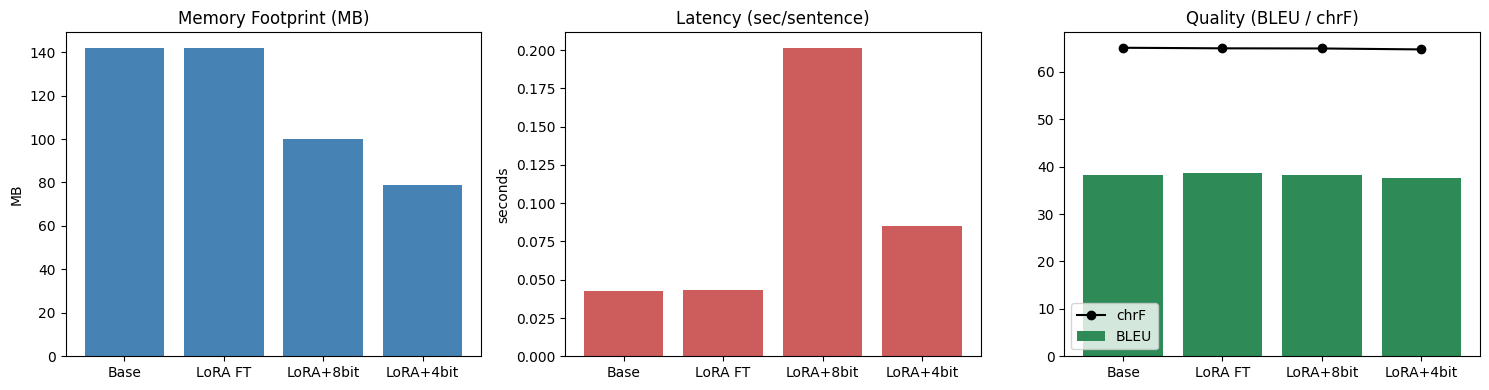

In [26]:
# ==== Cell 19: Visualize the trade-offs ====

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

stages_short = ["Base", "LoRA FT", "LoRA+8bit", "LoRA+4bit"]

axes[0].bar(stages_short, df["Memory (MB)"], color="steelblue")
axes[0].set_title("Memory Footprint (MB)")
axes[0].set_ylabel("MB")

axes[1].bar(stages_short, df["Latency (sec/sentence)"], color="indianred")
axes[1].set_title("Latency (sec/sentence)")
axes[1].set_ylabel("seconds")

axes[2].bar(stages_short, df["BLEU"], color="seagreen", label="BLEU")
axes[2].plot(stages_short, df["chrF"], color="black", marker="o", label="chrF")
axes[2].set_title("Quality (BLEU / chrF)")
axes[2].legend()

plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150)
plt.show()

In [27]:
# ==== Cell 20: Qualitative comparison ====

sample_sources = [eval_subset["translation"][i]["en"] for i in range(5)]
sample_references = [eval_subset["translation"][i]["de"] for i in range(5)]

for i in range(5):
    print(f"\n--- Example {i+1} ---")
    print(f"EN source:    {sample_sources[i]}")
    print(f"DE reference: {sample_references[i]}")
    for stage_key in ["1_base_pretrained", "2_lora_finetuned", "3_lora_8bit", "4_lora_4bit"]:
        print(f"{stage_key}: {example_translations[stage_key][i]}")


--- Example 1 ---
EN source:    Obama receives Netanyahu
DE reference: Obama empfängt Netanyahu
1_base_pretrained: Obama erhält Netanjahu
2_lora_finetuned: Obama empfängt Netanjahu
3_lora_8bit: Obama empfängt Netanjahu
4_lora_4bit: Obama erhält Netanjahu

--- Example 2 ---
EN source:    The relationship between Obama and Netanyahu is not exactly friendly.
DE reference: Das Verhältnis zwischen Obama und Netanyahu ist nicht gerade freundschaftlich.
1_base_pretrained: Die Beziehung zwischen Obama und Netanjahu ist nicht gerade freundlich.
2_lora_finetuned: Die Beziehung zwischen Obama und Netanjahu ist nicht gerade freundlich.
3_lora_8bit: Die Beziehung zwischen Obama und Netanjahu ist nicht gerade freundlich.
4_lora_4bit: Die Beziehung zwischen Obama und Netanjahu ist nicht gerade freundlich.

--- Example 3 ---
EN source:    The two wanted to talk about the implementation of the international agreement and about Teheran's destabilising activities in the Middle East.
DE reference: Die be